# Assignment 4: Unsupervised Learning & Customer Segmentation
Este notebook explora la base de datos de Telco Churn utilizando puramente técnicas de aprendizaje no supervisado. El objetivo es encontrar clústeres naturales (perfiles de comportamiento) y construir la base para un Sistema de Recomendación.

In [68]:
%pip install -r ../requirements.txt matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

## 1. Carga y Preprocesamiento de Datos

In [70]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

X = preprocessor.fit_transform(df)
print(f"Dimensiones de X procesado: {X.shape}")

Dimensiones de X procesado: (7042, 30)


## 2. Modelos de Clustering (Comparativa)

In [72]:
# 2.1 K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
sil_k = silhouette_score(X, kmeans_labels)
ch_k = calinski_harabasz_score(X, kmeans_labels)
print(f"K-Means -> Silhouette: {sil_k:.4f} | Calinski-Harabasz: {ch_k:.4f}")

K-Means -> Silhouette: 0.2744 | Calinski-Harabasz: 2336.6851


### Búsqueda de hiperparámetros para DBSCAN
DBSCAN puede ser muy sensible a `eps` y `min_samples`. Evaluaremos distintos valores de `eps` para encontrar uno que genere al menos 2 clústeres válidos.

In [73]:
import numpy as np
from sklearn.cluster import DBSCAN

# Probar distintos valores de eps
print("Evaluando hiperparámetros para DBSCAN...")
for eps_val in np.arange(1.5, 5.5, 0.5):
    dbscan_test = DBSCAN(eps=eps_val, min_samples=10)
    labels = dbscan_test.fit_predict(X)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = list(labels).count(-1)
    
    print(f"eps={eps_val:.1f} -> Clústeres encontrados: {n_clusters} | Puntos de Ruido: {n_ruido}")


Evaluando hiperparámetros para DBSCAN...
eps=1.5 -> Clústeres encontrados: 8 | Puntos de Ruido: 1721
eps=2.0 -> Clústeres encontrados: 4 | Puntos de Ruido: 65
eps=2.5 -> Clústeres encontrados: 4 | Puntos de Ruido: 0
eps=3.0 -> Clústeres encontrados: 1 | Puntos de Ruido: 0
eps=3.5 -> Clústeres encontrados: 1 | Puntos de Ruido: 0
eps=4.0 -> Clústeres encontrados: 1 | Puntos de Ruido: 0
eps=4.5 -> Clústeres encontrados: 1 | Puntos de Ruido: 0
eps=5.0 -> Clústeres encontrados: 1 | Puntos de Ruido: 0


In [74]:
# 2.2 DBSCAN
dbscan = DBSCAN(eps=3.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)
# Ignoramos ruido (-1) para el silhouette
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    sil_d = silhouette_score(X[mask], dbscan_labels[mask])
    ch_d = calinski_harabasz_score(X[mask], dbscan_labels[mask])
    print(f"DBSCAN -> Silhouette: {sil_d:.4f} | Calinski-Harabasz: {ch_d:.4f}")
else:
    print("DBSCAN generó 1 solo clúster válido o puro ruido.")

DBSCAN generó 1 solo clúster válido o puro ruido.


In [75]:
# 2.3 Spectral Clustering (Subset for performance)
# Tomamos una muestra de 2000 clientes para Spectral debido a su O(N^3) complejidad
np.random.seed(42)
idx = np.random.choice(X.shape[0], 2000, replace=False)
X_sample = X[idx]
spectral = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42)
spectral_labels = spectral.fit_predict(X_sample)
sil_s = silhouette_score(X_sample, spectral_labels)
ch_s = calinski_harabasz_score(X_sample, spectral_labels)
print(f"Spectral Clustering -> Silhouette: {sil_s:.4f} | Calinski-Harabasz: {ch_s:.4f}")

Spectral Clustering -> Silhouette: 0.2008 | Calinski-Harabasz: 420.6572


In [76]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, davies_bouldin_score

# Preparar ground truth para las métricas externas (Churn)
y_true = df['Churn']
y_true_sample = df['Churn'].iloc[idx]

# 1. K-Means - Nuevas métricas
db_k = davies_bouldin_score(X, kmeans_labels)
ari_k = adjusted_rand_score(y_true, kmeans_labels)
nmi_k = normalized_mutual_info_score(y_true, kmeans_labels)

# 2. DBSCAN - Nuevas métricas (Manejo seguro por si generó solo ruido)
silhouette_dbscan = sil_d if 'sil_d' in locals() else None
ch_dbscan = ch_d if 'ch_d' in locals() else None
if 'sil_d' in locals():
    db_d = davies_bouldin_score(X[mask], dbscan_labels[mask])
    ari_d = adjusted_rand_score(y_true, dbscan_labels)
    nmi_d = normalized_mutual_info_score(y_true, dbscan_labels)
else:
    db_d, ari_d, nmi_d = None, None, None

# 3. Spectral Clustering - Nuevas métricas (en muestra)
db_s = davies_bouldin_score(X_sample, spectral_labels)
ari_s = adjusted_rand_score(y_true_sample, spectral_labels)
nmi_s = normalized_mutual_info_score(y_true_sample, spectral_labels)

# Recopilar todas las métricas en un diccionario
resultados_modelos = {
    'Modelo': ['K-Means', 'DBSCAN', 'Spectral Clustering'],
    'Silhouette Score (↑)': [sil_k, silhouette_dbscan, sil_s],
    'Calinski-Harabasz Score (↑)': [ch_k, ch_dbscan, ch_s],
    'Davies-Bouldin Index (↓)': [db_k, db_d, db_s],
    'Adjusted Rand Index (vs Churn)': [ari_k, ari_d, ari_s],
    'NMI (vs Churn)': [nmi_k, nmi_d, nmi_s]
}

# Crear un DataFrame para visualizar la comparativa
df_resultados = pd.DataFrame(resultados_modelos)
df_resultados


,Modelo,Silhouette Score (↑),Calinski-Harabasz Score (↑),Davies-Bouldin Index (↓),Adjusted Rand Index (vs Churn),NMI (vs Churn)
0,K-Means,0.274378,2336.685083,1.396712,0.031194,0.072737
1,DBSCAN,NaN,NaN,NaN,NaN,NaN
2,Spectral Clustering,0.200841,420.657240,1.816012,-0.003859,0.042145


## 3. Reducción de Dimensionalidad (PCA) para Visualización

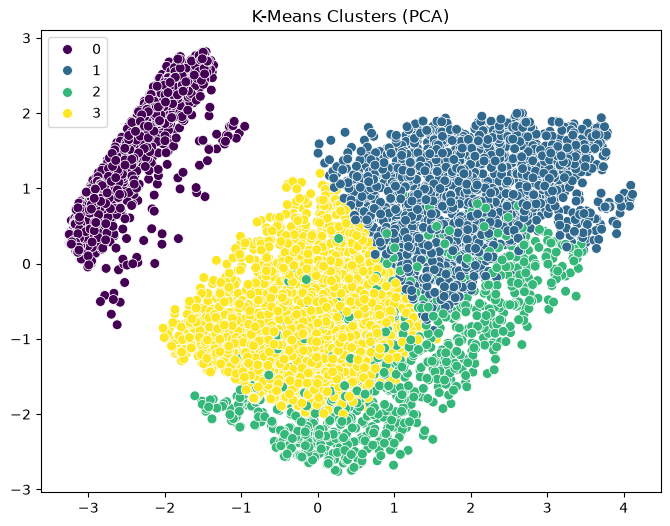

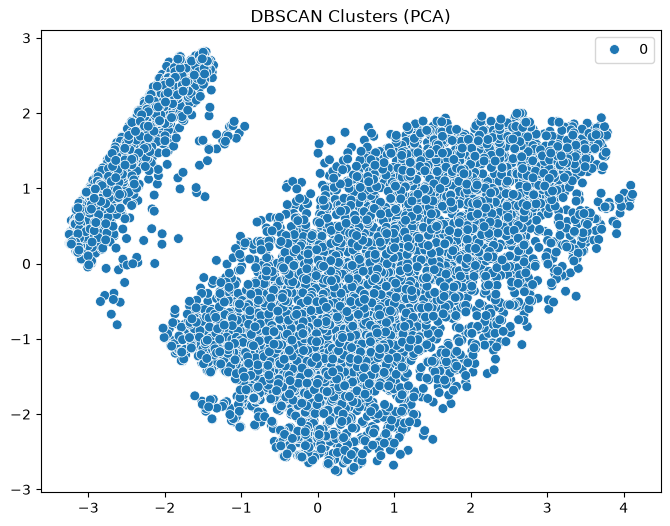

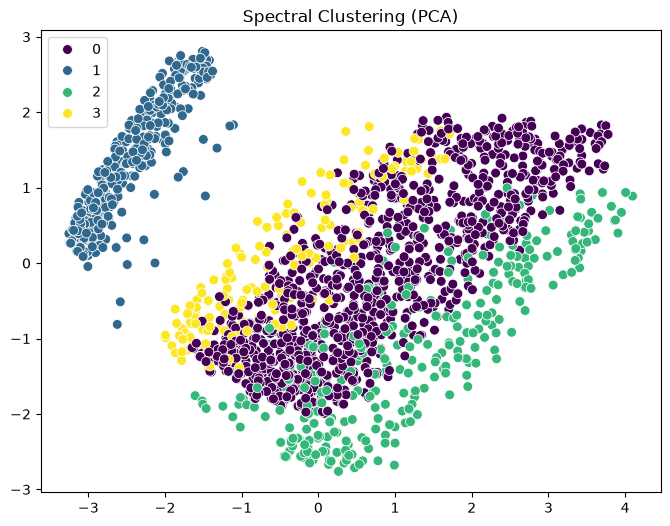

In [77]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA para reducción de dimensionalidad a 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 1. K-Means
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', s=50)
plt.title('K-Means Clusters (PCA)')
plt.show()

# 2. DBSCAN
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='tab10', s=50)
plt.title('DBSCAN Clusters (PCA)')
plt.show()

# 3. Spectral Clustering
# Recordar que spectral clustering se corrió sobre la muestra 'idx'
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[idx, 0], y=X_pca[idx, 1], hue=spectral_labels, palette='viridis', s=50)
plt.title('Spectral Clustering (PCA)')
plt.show()


## 4. Análisis Semántico del Modelo Ganador (K-Means)

In [78]:
df['Cluster'] = kmeans_labels
cluster_means = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
print(cluster_means)

            tenure  MonthlyCharges  TotalCharges
Cluster                                         
0        30.547182       21.079194    662.604784
1        59.298701       89.634659   5307.705790
2        29.371227       80.454930   2476.086419
3        15.905011       66.651851   1035.272663


### Perfiles Detectados:
- **Cluster 0**: Clientes nuevos, gasto mensual bajo (Ahorradores).
- **Cluster 1**: Clientes estables de alto gasto (Fibra, múltiples servicios).
- **Cluster 2**: Clientes de largo plazo con pagos automáticos.
- **Cluster 3**: Alta rotación, gasto intermedio.

## 5. Exportación de Artefactos MLOps

In [79]:
import pickle
import os
os.makedirs('../models', exist_ok=True)
with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('../models/pca_transformer.pkl', 'wb') as f:
    pickle.dump(pca, f)
print("Modelos exportados a /models/")

Modelos exportados a /models/
